# Implied Cancellation Proxy

This notebook does not read a literal cancel or replace feed. It infers **implied non-trade removal** from replayed book rows.

The goal is to answer three practical questions:

- how much visible depth disappears between two book states
- how much of that disappearance is explained by aggressive trades at the same price
- how much residual removal remains as a proxy for cancellation, replacement, or other non-trade queue turnover

The expensive outputs are cached under the day cache for the chosen `max_level`, so rerunning the notebook should load the saved parquet instead of recomputing the full proxy.

## Metric Definitions

For one side of the book and one tracked level, compare two consecutive replayed book rows.

- `prev_qty`: displayed quantity at the first book row
- `next_qty`: displayed quantity at the next book row
- `visible_reduction = max(prev_qty - next_qty, 0)`
- `trade_qty_at_price`: aggressive trade quantity executed at the same price between the two rows
- `price_stable`: whether the price at that level stayed unchanged between the two rows
- `implied_cancel_qty = max(visible_reduction - trade_qty_at_price, 0)` when `price_stable` is true

Interpretation:

- `visible_reduction` is what disappeared from the visible queue
- `trade_qty_at_price` is the part explained by trades
- `implied_cancel_qty` is the remaining part, which is a **proxy** for cancellation, replacement, or other non-trade removal

Important caveat:

- this is **not** a literal cancel message count
- if new liquidity appears at the same price before the next snapshot, the proxy is still only a lower bound on queue turnover

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display


def find_backtester_root() -> Path:
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / 'stats').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate the exchange-data-backtester project root')


PROJECT_ROOT = find_backtester_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from stats.notebook import load_orderflow_day
from stats.tables import get_or_build_book_levels_table
from stats.analysis.book_queue_common import build_layer_event_stream
from stats.analysis.trade_depletion import (
    get_or_build_implied_cancellations,
    get_or_build_trade_depletion,
)


In [2]:
REFERENCE_DAY = '20260223'
REPLAY_ON_GAP = 'skip-segment'
TRACKED_TOP_N = 10
MAX_LEVEL = 5

# `TRACKED_TOP_N` controls the replay depth kept in the book table.
# `MAX_LEVEL` controls how deep we summarize the cancellation proxy.

print(f'Loading {REFERENCE_DAY} ...')
dataset, trades, top, summary = load_orderflow_day(
    day=REFERENCE_DAY,
    replay_on_gap=REPLAY_ON_GAP,
    project_root=PROJECT_ROOT,
)
book_levels = get_or_build_book_levels_table(
    dataset,
    top_n=TRACKED_TOP_N,
    on_gap=REPLAY_ON_GAP,
    show_progress=False,
)
stream = build_layer_event_stream(book_levels, trades)

display(summary.to_frame('value'))
print(f'book_levels rows: {len(book_levels):,}')
print(f'trades rows: {len(trades):,}')
print(f'event stream rows: {len(stream):,}')

Loading 20260223 ...


,value
exchange,binance
symbol,BTCUSDC
day,20260223
day_dir,/Users/hoangdeveloper/PycharmProjects/exchange...
trades_rows,868008
top_rows,722893
trade_start_utc,2026-02-23 01:00:04.958000+00:00
trade_end_utc,2026-02-23 23:15:00.320000+00:00
top_start_utc,2026-02-23 01:00:04.735000+00:00
top_end_utc,2026-02-23 23:14:59.835000+00:00


book_levels rows: 722,893
trades rows: 868,008
event stream rows: 1,590,901


## Summary Units

`implied_cancel_qty_mean` is the average inferred non-trade removal **per consecutive book-to-book interval** for that side and level.

So if level 1 shows `0.14`, read it as:

> across all consecutive replayed book updates where that side/level was observable, the average residual visible quantity removed at that level was about `0.14 BTC` per book-update interval.

It is not `0.14 BTC per minute` and not `0.14 BTC over the whole day`. The time length of each interval is whatever elapsed between two consecutive replayed book rows. To convert this into a time-based rate later, aggregate by clock time, for example `sum(implied_cancel_qty)` per second or per minute.

Rows where the level price changed are not assigned an implied cancel quantity in this proxy, because the current definition only estimates fixed-level, fixed-price residual removal.

In [3]:
implied = get_or_build_implied_cancellations(
    stream,
    day_dir=dataset.day_dir,
    max_level=MAX_LEVEL,
    show_progress=True,
).copy()
depletion = get_or_build_trade_depletion(
    stream,
    day_dir=dataset.day_dir,
    max_level=MAX_LEVEL,
    show_progress=True,
).copy()

if implied.empty:
    raise RuntimeError('No implied cancellation rows were produced for the selected day')

implied['residual_share'] = implied['implied_cancel_qty'] / implied['visible_reduction'].replace(0.0, np.nan)

implied_summary = (
    implied.groupby(['book_side', 'aggressor_side', 'level'], sort=True)
    .agg(
        observations=('implied_cancel_qty', 'size'),
        price_stable_share=('price_stable', 'mean'),
        visible_reduction_mean=('visible_reduction', 'mean'),
        trade_qty_at_price_mean=('trade_qty_at_price', 'mean'),
        implied_cancel_qty_mean=('implied_cancel_qty', 'mean'),
        implied_cancel_qty_median=('implied_cancel_qty', 'median'),
        residual_share_mean=('residual_share', 'mean'),
        residual_share_median=('residual_share', 'median'),
        positive_implied_share=('implied_cancel_qty', lambda s: float((s.fillna(0.0) > 0).mean())),
    )
    .reset_index()
)

plot_implied_summary = (
    implied.groupby(['book_side', 'level'], sort=True)
    .agg(
        observations=('implied_cancel_qty', 'size'),
        price_stable_share=('price_stable', 'mean'),
        implied_cancel_qty_mean=('implied_cancel_qty', 'mean'),
        residual_share_mean=('residual_share', 'mean'),
        positive_implied_share=('implied_cancel_qty', lambda s: float((s.fillna(0.0) > 0).mean())),
    )
    .reset_index()
)

depletion_summary = (
    depletion.groupby(['book_side', 'level'], sort=True)
    .agg(
        observations=('delay_ms', 'size'),
        censored_share=('censored', 'mean'),
        median_delay_ms=('delay_ms', 'median'),
        mean_delay_ms=('delay_ms', 'mean'),
        p90_delay_ms=('delay_ms', lambda s: float(np.nanquantile(s.dropna(), 0.90)) if s.dropna().size else np.nan),
    )
    .reset_index()
)

print('Implied cancellation summary:')
display(implied_summary)
print('Trade depletion summary:')
display(depletion_summary)

Implied cancellation summary:


,book_side,aggressor_side,level,observations,price_stable_share,visible_reduction_mean,trade_qty_at_price_mean,implied_cancel_qty_mean,implied_cancel_qty_median,residual_share_mean,residual_share_median,positive_implied_share
0,ask,buy,1,722892,0.894964,0.021790,0.002338,0.014907,0.0,0.834308,1.0,0.169011
1,ask,buy,2,722892,0.780721,0.007227,0.000187,0.001158,0.0,0.999174,1.0,0.034626
2,ask,buy,3,722892,0.729525,0.008857,0.000196,0.001081,0.0,0.999140,1.0,0.011978
3,ask,buy,4,722892,0.699394,0.009785,0.000184,0.000790,0.0,0.999653,1.0,0.007967
4,ask,buy,5,722892,0.681084,0.010426,0.000155,0.000556,0.0,0.999727,1.0,0.005484
5,bid,sell,1,722892,0.894975,0.021449,0.002115,0.014847,0.0,0.899547,1.0,0.160927
6,bid,sell,2,722892,0.781144,0.007502,0.000173,0.001085,0.0,0.999123,1.0,0.031035
7,bid,sell,3,722892,0.733491,0.009843,0.000176,0.001097,0.0,0.999586,1.0,0.013348
8,bid,sell,4,722892,0.702653,0.011306,0.000191,0.000798,0.0,0.998886,1.0,0.008680
9,bid,sell,5,722892,0.685336,0.012596,0.000160,0.000614,0.0,1.000000,1.0,0.006069


Trade depletion summary:


,book_side,level,observations,censored_share,median_delay_ms,mean_delay_ms,p90_delay_ms
0,ask,1,722893,0.001151,12134.0,20037.167232,48161.0
1,ask,2,722893,0.001206,12919.0,21226.838761,50831.0
2,ask,3,722893,0.001317,14355.0,23127.007905,54913.0
3,ask,4,722893,0.001379,15786.0,25112.558924,58874.0
4,ask,5,722893,0.001436,17220.0,27065.930407,62895.0
5,bid,1,722893,0.000458,12738.0,21257.130989,51959.0
6,bid,2,722893,0.000527,13620.0,22508.837956,54569.9
7,bid,3,722893,0.000538,15069.0,24528.305063,58948.0
8,bid,4,722893,0.000588,16535.0,26553.765594,63012.0
9,bid,5,722893,0.000657,18037.0,28649.587851,67404.6


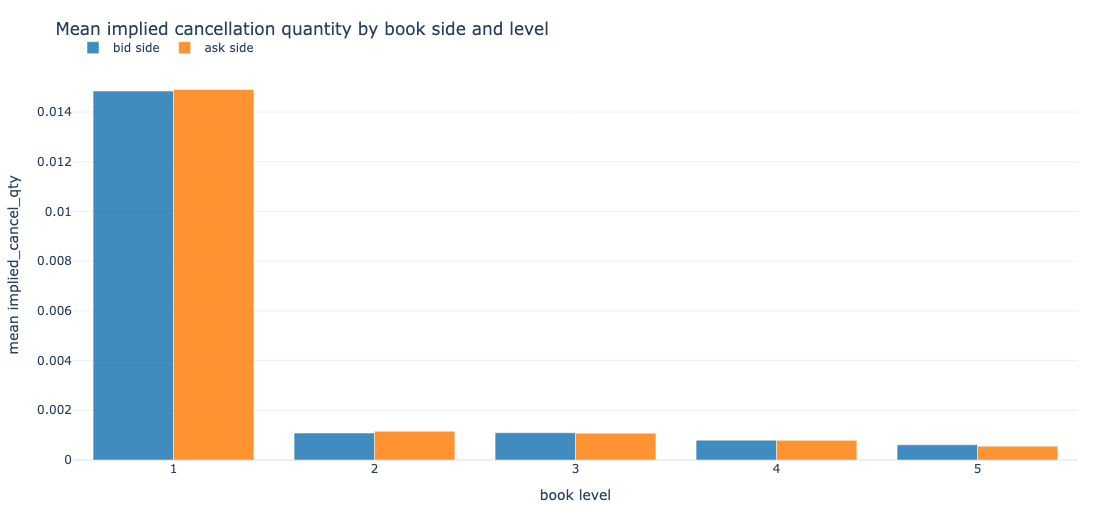

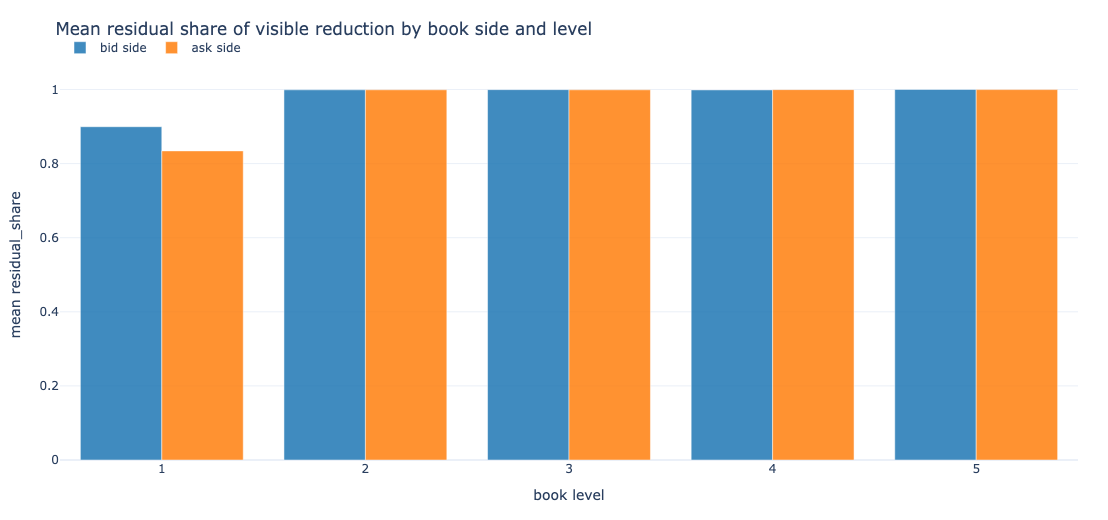

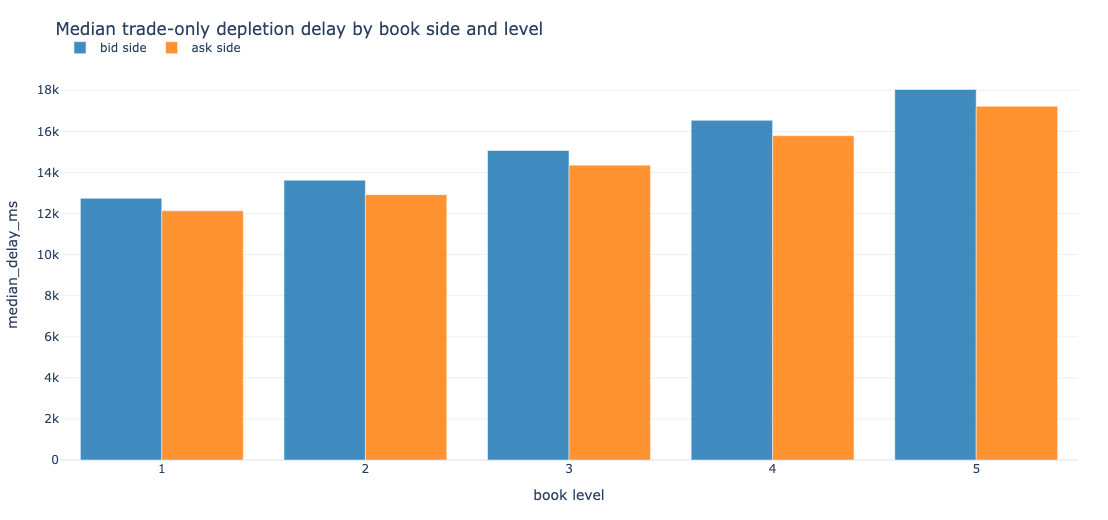

In [4]:
def _plot_side_level_bars(df: pd.DataFrame, *, value_col: str, title: str, y_title: str) -> go.Figure:
    fig = make_subplots(rows=1, cols=1)
    colors = {'bid': '#1f77b4', 'ask': '#ff7f0e'}
    for side in ['bid', 'ask']:
        side_df = df[df['book_side'] == side].sort_values('level')
        if side_df.empty:
            continue
        fig.add_trace(
            go.Bar(
                x=side_df['level'],
                y=side_df[value_col],
                name=f'{side} side',
                marker_color=colors[side],
                opacity=0.85,
                hovertemplate='level=%{x}<br>value=%{y:.6f}<extra></extra>',
            )
        )
    fig.update_layout(
        template='plotly_white',
        width=1280,
        height=520,
        barmode='group',
        title=title,
        margin=dict(l=60, r=30, t=70, b=60),
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0.0),
    )
    fig.update_xaxes(title_text='book level')
    fig.update_yaxes(title_text=y_title)
    return fig


fig1 = _plot_side_level_bars(
    plot_implied_summary,
    value_col='implied_cancel_qty_mean',
    title='Mean implied cancellation quantity by book side and level',
    y_title='mean implied_cancel_qty',
)
fig1.show()

fig2 = _plot_side_level_bars(
    plot_implied_summary,
    value_col='residual_share_mean',
    title='Mean residual share of visible reduction by book side and level',
    y_title='mean residual_share',
)
fig2.show()

fig3 = _plot_side_level_bars(
    depletion_summary,
    value_col='median_delay_ms',
    title='Median trade-only depletion delay by book side and level',
    y_title='median_delay_ms',
)
fig3.show()

## Price And Cancellation Pressure

This view buckets the implied cancellation proxy into clock time so it can be compared with the price curve.

- `ask cancel rate` and `bid cancel rate` are the implied cancellation quantities per second, aggregated into one-minute bars and then smoothed with a short rolling average.
- `cancellation imbalance = (ask rate - bid rate) / (ask rate + bid rate)`.
- Positive values mean more ask-side implied removal; negative values mean more bid-side implied removal.

This is a clock-time summary of the proxy, not a literal cancel feed.


In [ ]:
PLOT_FREQ = '1min'
SMOOTH_MIN = 5

price_grid = (
    top.loc[:, ['ts', 'mid']]
    .dropna()
    .sort_values('ts')
    .set_index('ts')
    .resample(PLOT_FREQ)
    .last()
    .ffill()
)

cancel_base = implied.loc[implied['implied_cancel_qty'].notna() & (implied['interval_ms'] > 0)].copy()
cancel_base['ts'] = pd.to_datetime(cancel_base['book_time_ms'], unit='ms', utc=True)


def _build_cancel_rate_series(frame: pd.DataFrame, *, side: str) -> pd.Series:
    part = frame.loc[frame['book_side'] == side, ['ts', 'implied_cancel_qty', 'interval_ms']].copy()
    if part.empty:
        return pd.Series(dtype='float64', name=f'{side}_cancel_rate_per_sec')
    agg = (
        part.set_index('ts')
        .resample(PLOT_FREQ)
        .agg(cancel_qty=('implied_cancel_qty', 'sum'), covered_ms=('interval_ms', 'sum'))
    )
    covered_sec = agg['covered_ms'].replace(0, np.nan) / 1000.0
    series = (agg['cancel_qty'] / covered_sec).rename(f'{side}_cancel_rate_per_sec')
    return series

ask_cancel_rate = _build_cancel_rate_series(cancel_base, side='ask')
bid_cancel_rate = _build_cancel_rate_series(cancel_base, side='bid')

cancel_frame = pd.concat(
    [
        price_grid['mid'],
        ask_cancel_rate,
        bid_cancel_rate,
    ],
    axis=1,
).sort_index()

cancel_frame['ask_cancel_rate_ma'] = cancel_frame['ask_cancel_rate_per_sec'].rolling(
    SMOOTH_MIN,
    min_periods=max(2, SMOOTH_MIN // 2),
).mean()
cancel_frame['bid_cancel_rate_ma'] = cancel_frame['bid_cancel_rate_per_sec'].rolling(
    SMOOTH_MIN,
    min_periods=max(2, SMOOTH_MIN // 2),
).mean()

cancel_denom = (cancel_frame['ask_cancel_rate_ma'] + cancel_frame['bid_cancel_rate_ma']).replace(0, np.nan)
cancel_frame['cancel_imbalance'] = (
    cancel_frame['ask_cancel_rate_ma'] - cancel_frame['bid_cancel_rate_ma']
) / cancel_denom

fig = make_subplots(
    rows=3,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.06,
    row_heights=[0.42, 0.30, 0.28],
    subplot_titles=(
        'Midprice',
        f'Implied cancellation rate per second | {PLOT_FREQ} bars | MA {SMOOTH_MIN}',
        'Cancellation imbalance',
    ),
)

fig.add_trace(
    go.Scattergl(
        x=price_grid.index,
        y=price_grid['mid'],
        mode='lines',
        name='midprice',
        line=dict(color='#2f3640', width=1.2),
        hovertemplate='%{x}<br>mid=%{y:.2f}<extra></extra>',
    ),
    row=1,
    col=1,
)

fig.add_trace(
    go.Scattergl(
        x=cancel_frame.index,
        y=cancel_frame['ask_cancel_rate_ma'],
        mode='lines',
        name='ask cancel rate',
        line=dict(color='#ff7f0e', width=2.0),
        hovertemplate='%{x}<br>ask cancel rate=%{y:.4f}<extra></extra>',
    ),
    row=2,
    col=1,
)
fig.add_trace(
    go.Scattergl(
        x=cancel_frame.index,
        y=cancel_frame['bid_cancel_rate_ma'],
        mode='lines',
        name='bid cancel rate',
        line=dict(color='#1f77b4', width=2.0),
        hovertemplate='%{x}<br>bid cancel rate=%{y:.4f}<extra></extra>',
    ),
    row=2,
    col=1,
)

fig.add_trace(
    go.Scattergl(
        x=cancel_frame.index,
        y=cancel_frame['cancel_imbalance'],
        mode='lines',
        name='cancellation imbalance',
        line=dict(color='#7c3aed', width=2.0),
        hovertemplate='%{x}<br>cancel imbalance=%{y:.3f}<extra></extra>',
    ),
    row=3,
    col=1,
)
fig.add_hline(
    y=0.0,
    line_dash='dash',
    line_color='#6b7280',
    row=3,
    col=1,
    annotation_text='balanced cancellation pressure = 0',
    annotation_position='top right',
)

fig.update_yaxes(title_text='midprice', row=1, col=1)
fig.update_yaxes(title_text='cancel rate / sec', row=2, col=1)
fig.update_yaxes(title_text='cancel imbalance', row=3, col=1, range=[-1.05, 1.05])
fig.update_xaxes(title_text='UTC', row=3, col=1)
fig.update_layout(
    template='plotly_white',
    width=1280,
    height=980,
    hovermode='x unified',
    title=f'Price and implied cancellation pressure | {REFERENCE_DAY}',
    margin=dict(l=60, r=30, t=80, b=60),
    legend=dict(orientation='h', yanchor='bottom', y=1.01, xanchor='left', x=0.0),
)
fig.show()


In [5]:
examples = (
    implied.sort_values('implied_cancel_qty', ascending=False)
    .loc[:, [
        'book_side',
        'aggressor_side',
        'level',
        'book_recv_seq',
        'next_book_recv_seq',
        'prev_price',
        'next_price',
        'prev_qty',
        'next_qty',
        'trade_qty_at_price',
        'visible_reduction',
        'implied_cancel_qty',
        'residual_share',
        'price_stable',
    ]]
    .head(20)
)

display(examples)

,book_side,aggressor_side,level,book_recv_seq,next_book_recv_seq,prev_price,next_price,prev_qty,next_qty,trade_qty_at_price,visible_reduction,implied_cancel_qty,residual_share,price_stable
6884966,ask,buy,2,1524681,1524686,64767.31,64767.31,8.33024,0.00048,0.00000,8.32976,8.32976,1.000000,True
44605,ask,buy,1,23045,23047,65996.85,65996.85,4.78330,0.08214,0.02498,4.70116,4.67618,0.994686,True
6479905,ask,buy,1,1433640,1433655,64300.00,64300.00,36.14103,29.94363,2.37293,6.19740,3.82447,0.617109,True
136540,bid,sell,1,67358,67359,65090.98,65090.98,4.20631,0.41023,0.00000,3.79608,3.79608,1.000000,True
175171,bid,sell,2,83504,83505,65139.00,65139.00,3.80475,0.09192,0.00000,3.71283,3.71283,1.000000,True
115590,bid,sell,1,59245,59246,65192.63,65192.63,4.01428,0.31529,0.00000,3.69899,3.69899,1.000000,True
87630,bid,sell,1,48436,48437,65524.55,65524.55,3.97632,0.28210,0.00000,3.69422,3.69422,1.000000,True
162660,bid,sell,1,80329,80330,65018.98,65018.98,3.93099,0.24340,0.00000,3.68759,3.68759,1.000000,True
103470,bid,sell,1,54812,54814,65246.32,65246.32,3.88598,0.23803,0.00000,3.64795,3.64795,1.000000,True
276850,bid,sell,1,105619,105620,64992.99,64992.99,3.85344,0.21261,0.00000,3.64083,3.64083,1.000000,True


## How To Read The Output

- The bar charts show the average proxy size by book level.
- A larger `implied_cancel_qty` means more visible depth disappeared without trades explaining it.
- A larger `residual_share` means a larger fraction of the visible reduction is left over after subtracting same-price trade quantity.
- The trade-depletion chart is a benchmark: it shows how long aggressive flow alone would take to match the visible queue size.

The proxy is useful because it separates trade-driven removal from residual queue turnover, but it still does not identify literal cancel vs replace messages.